In [27]:
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
import os
load_dotenv()

if os.environ['GOOGLE_API_KEY'] == "":
    raise ValueError("GOOGLE_API_KEY is not set in the .env file.")
else:
    print("GOOGLE_API_KEY is set correctly.")

GOOGLE_API_KEY is set correctly.


In [28]:
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash",)
llm

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain-google-genai': '4.2.6'}}, output_version=None, profile={'name': 'Gemini 3.5 Flash', 'release_date': '2026-05-19', 'last_updated': '2026-05-19', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-3.5-flash', temperature=1.0, client=<google.genai.client.Client object at 0x000002C48FC1DF30>, default_metadata=(), model_kwargs={})

In [ ]:
from typing import TypedDict, List
from operator import add

class graph_schema(TypedDict):
    messages_manual: List
    # messages_auto: Annotated[List, add] doing this makes the the change below (look commented) (this is called 'reducer')

In [ ]:
from langchain_core.messages import AIMessage

def node_1(state: graph_schema) -> graph_schema:
    messages_manual = state['messages_manual']

    response_manual = llm.invoke(messages_manual).content[0].get('text')
    response_manual_AI = AIMessage(content=response_manual)

    state['messages_manual'] = messages_manual + [response_manual_AI]
    # state['messages_manual'] = [response_manual_AI]  this can be done

    return state

In [31]:
def node_2(state: graph_schema) -> graph_schema:
    messages_manual = state['messages_manual']

    response_manual = llm.invoke(f"continue this conversation: {messages_manual}").content[0].get('text')
    response_manual_AI = AIMessage(content=response_manual)

    state['messages_manual'] = messages_manual + [response_manual_AI]

    return state

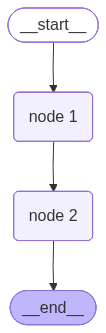

In [32]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image

graph = StateGraph(graph_schema)
graph.add_node("node 1", node_1)
graph.add_node("node 2", node_2)

graph.add_edge(START, "node 1")
graph.add_edge("node 1", "node 2")
graph.add_edge("node 2", END)

sample_graph = graph.compile()
Image(sample_graph.get_graph().draw_mermaid_png())

In [33]:
from langchain_core.messages import HumanMessage

sample_graph.invoke(
    {"messages_manual": [HumanMessage(content="Hello, how are you?")]}
)

{'messages_manual': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Hello! I'm doing well, thank you for asking. How are you? How can I help you today?", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='Here is a continuation of the conversation in the same format, assuming the human responds with a request for assistance:\n\n```python\n[\n    # ... previous messages ...\n    HumanMessage(\n        content="I\'m doing great, thanks! I\'m actually working on a coding project and was wondering if you could help me write a Python function.",\n        additional_kwargs={},\n        response_metadata={}\n    ),\n    AIMessage(\n        content="I\'d be happy to help with your Python project! What kind of function are you trying to write? Let me know what you want it to do, and we can get started.",\n        additional_kwargs={},\n        response_metadata={},\n        tool_c